# Diamonds regression

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm

In [2]:
df = pd.read_csv("diamonds.csv")
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [3]:
columns = ["carat", "depth", "table", "x", "y", "z", "price"]

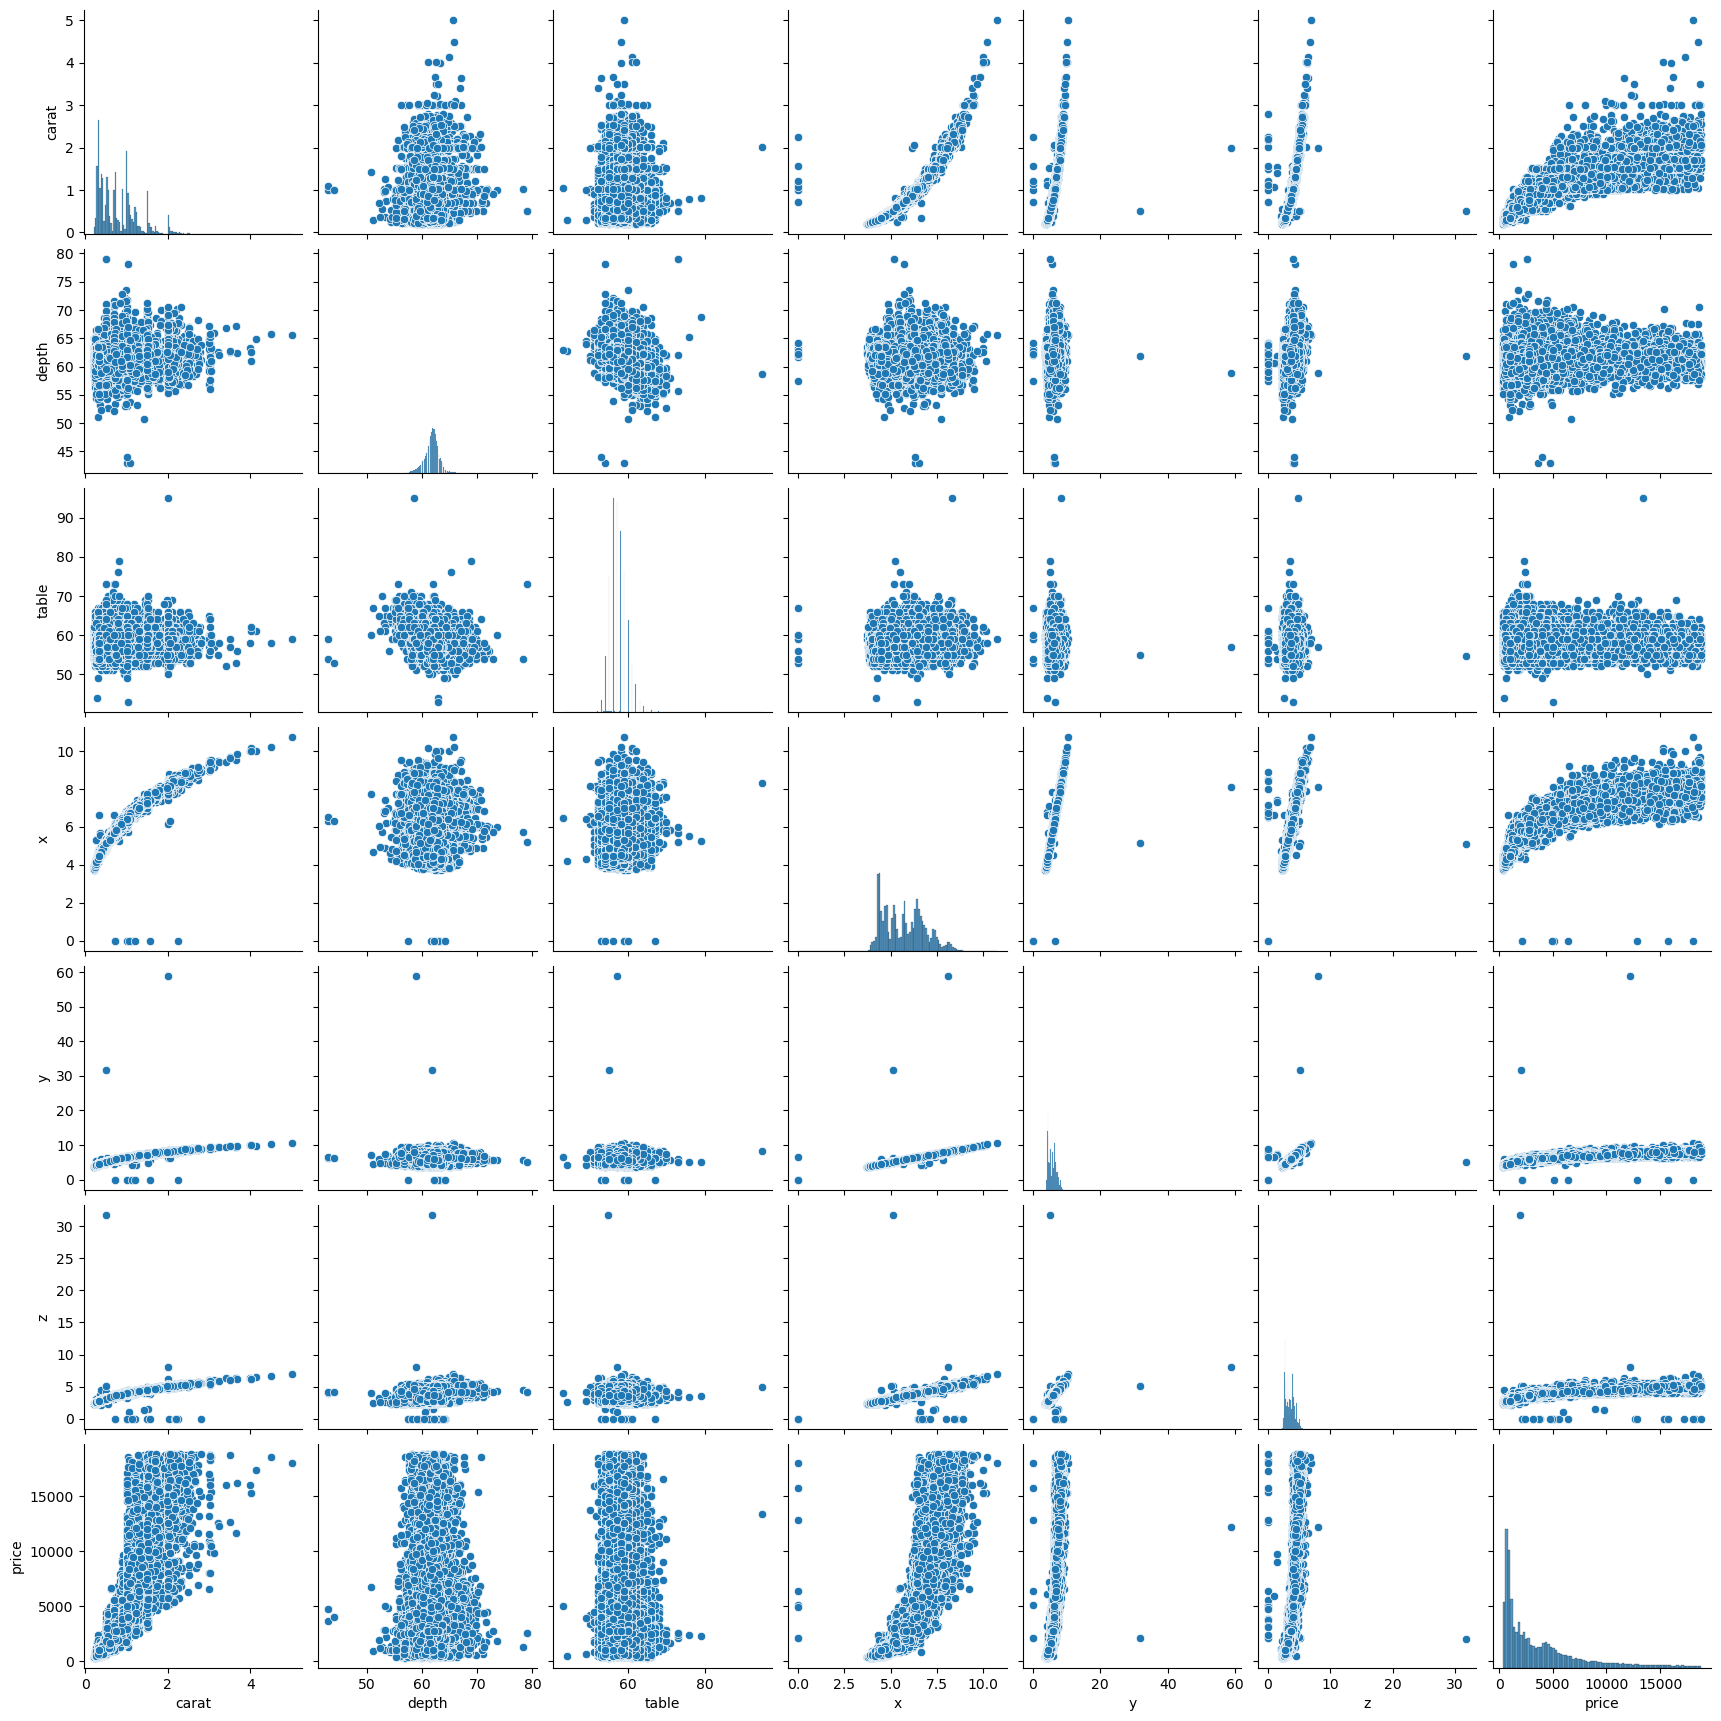

In [4]:
sns.pairplot(df[columns])

In [5]:
df[columns].corr()

,carat,depth,table,x,y,z,price
carat,1.000000,0.028266,0.181643,0.975095,0.951724,0.953389,0.921593
depth,0.028266,1.000000,-0.295735,-0.025252,-0.029301,0.094964,-0.010613
table,0.181643,-0.295735,1.000000,0.195365,0.183783,0.150955,0.127155
x,0.975095,-0.025252,0.195365,1.000000,0.974702,0.970772,0.884438
y,0.951724,-0.029301,0.183783,0.974702,1.000000,0.952007,0.865425
z,0.953389,0.094964,0.150955,0.970772,0.952007,1.000000,0.861253
price,0.921593,-0.010613,0.127155,0.884438,0.865425,0.861253,1.000000


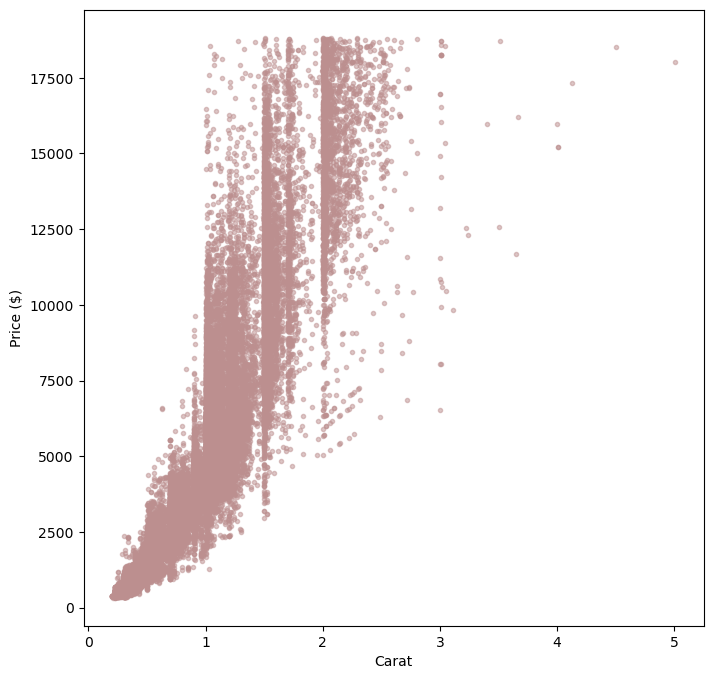

In [6]:
plt.figure(figsize=(8,8))
plt.scatter(df["carat"], df["price"], color="RosyBrown", alpha=0.5, marker=".")
plt.xlabel("Carat")
plt.ylabel("Price ($)")
plt.show()

In [7]:
Y = df["price"]
X = sm.add_constant(df["carat"]) # adds intercept!

In [8]:
X

,const,carat
0,1.0,0.23
1,1.0,0.21
2,1.0,0.23
3,1.0,0.29
4,1.0,0.31
...,...,...
53936,1.0,0.72
53937,1.0,0.72
53938,1.0,0.70
53939,1.0,0.86


In [9]:
Y

0         326
1         326
2         327
3         334
4         335
         ... 
53936    2757
53937    2757
53938    2757
53939    2757
53940    2757
Name: price, Length: 53941, dtype: int64

In [10]:
model = sm.OLS(Y, X) # must start with Y
results = model.fit() # training process

In [11]:
results

In [12]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.849
Model:                            OLS   Adj. R-squared:                  0.849
Method:                 Least Squares   F-statistic:                 3.041e+05
Date:                Sun, 07 Jun 2026   Prob (F-statistic):               0.00
Time:                        22:16:47   Log-Likelihood:            -4.7274e+05
No. Observations:               53941   AIC:                         9.455e+05
Df Residuals:                   53939   BIC:                         9.455e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2256.3385     13.055   -172.831      0.0

In [13]:
# equation of line of best fit -> price = m*carat + b
results.params # coefficients

const   -2256.338481
carat    7756.379377
dtype: float64

In [14]:
type(results.params)

pandas.core.series.Series

In [15]:
m = results.params["carat"]
b = results.params["const"]

In [16]:
carat = 1.5
price = m*carat + b

In [17]:
print(price)

9378.230584795825


In [18]:
# generate new possible diamonds
# random samples from uniform distribution
carats = np.random.uniform(low=0.5, high=2.5, size=20)

In [19]:
print(carats)

[1.62548806 2.3627865  1.88030507 2.2295465  1.46399712 0.97948896
 1.51669158 1.40179639 0.73832667 0.89372396 2.03135132 1.17763507
 0.53137247 1.91517985 0.95965755 0.67498518 1.46909077 1.74393226
 0.59053988 1.95597185]


In [20]:
type(carats)

numpy.ndarray

In [21]:
prices = m*carats + b

In [22]:
print(prices) # estimated prices for each diamond

[10351.56356463 16070.32998612 12328.02099124 15036.87004732
  9098.97859662  5340.9494881   9507.69683129  8616.52615508
  3470.40327188  4675.72361188 13499.59302464  6877.84585858
  1865.18797881 12598.52304733  5187.12951872  2979.10267936
  9138.48688468 11270.26169734  2324.11288832 12914.92125984]


In [23]:
# multiple linear regression model
predictors = [
    "carat",
    "x"
]

Y = df["price"]
X = sm.add_constant(df[predictors])
model = sm.OLS(Y, X)
results = model.fit()

In [24]:
X

,const,carat,x
0,1.0,0.23,3.95
1,1.0,0.21,3.89
2,1.0,0.23,4.05
3,1.0,0.29,4.20
4,1.0,0.31,4.34
...,...,...,...
53936,1.0,0.72,5.75
53937,1.0,0.72,5.69
53938,1.0,0.70,5.66
53939,1.0,0.86,6.15


In [25]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.853
Model:                            OLS   Adj. R-squared:                  0.853
Method:                 Least Squares   F-statistic:                 1.570e+05
Date:                Sun, 07 Jun 2026   Prob (F-statistic):               0.00
Time:                        22:17:30   Log-Likelihood:            -4.7199e+05
No. Observations:               53941   AIC:                         9.440e+05
Df Residuals:                   53938   BIC:                         9.440e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1737.7139    103.622     16.770      0.0

In [26]:
df.loc[20107]

carat       1.5
cut        Good
color         I
clarity     SI1
depth      64.0
table      60.0
price      8580
x          7.13
y          7.25
z           4.6
Name: 20107, dtype: object

In [27]:
carat = 1.5
x = 7.13
m1 = results.params["carat"]
m2 = results.params["x"]
b =results.params["const"]

price = m1*carat + m2*x + b

In [28]:
print(price)

9605.36613408896


In [29]:
# multiple linear regression model
predictors = [
    "carat",
    "x",
    "y",
    "z"
]

Y = df["price"]
X = sm.add_constant(df[predictors])
model = sm.OLS(Y, X)
results = model.fit()

In [30]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.854
Model:                            OLS   Adj. R-squared:                  0.854
Method:                 Least Squares   F-statistic:                 7.892e+04
Date:                Sun, 07 Jun 2026   Prob (F-statistic):               0.00
Time:                        22:17:42   Log-Likelihood:            -4.7188e+05
No. Observations:               53941   AIC:                         9.438e+05
Df Residuals:                   53936   BIC:                         9.438e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1921.0000    104.372     18.405      0.0

In [31]:
carat = 1.5
x = 7.13
y = 7.25
z = 4.6
m1 = results.params["carat"]
m2 = results.params["x"]
m3 = results.params["y"]
m4 = results.params["z"]
b =results.params["const"]

price = m1*carat + m2*x + m3*y + m4*z + b

In [32]:
print(price)

9520.783644767513


In [33]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [34]:
print(pd.unique(df["color"].sort_values()))

['D' 'E' 'F' 'G' 'H' 'I' 'J']


C:\Users\chenyux\AppData\Local\Temp\ipykernel_32888\2185394216.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(df, x="color", y="price", order=color_order, palette="YlOrBr")


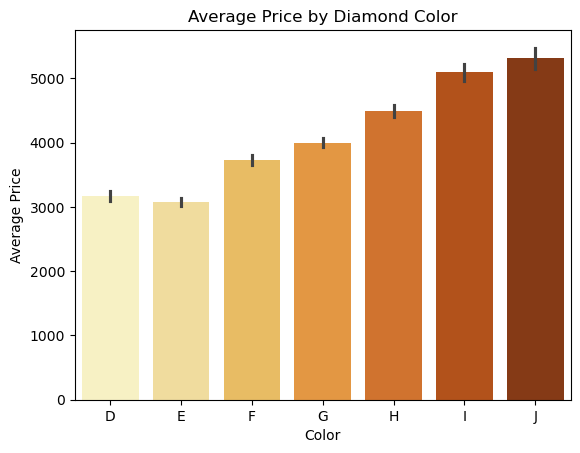

In [35]:
# Set the order of colors from D to J
color_order = ["D", "E", "F", "G", "H", "I", "J"]

# Create the barplot
sns.barplot(df, x="color", y="price", order=color_order, palette="YlOrBr")

# Customize plot
plt.title("Average Price by Diamond Color")
plt.xlabel("Color")
plt.ylabel("Average Price")
plt.show()

In [36]:
predictors = [
    "carat",
    "color"
]

Y = df["price"]
X = sm.add_constant(pd.get_dummies(df[predictors], columns=["color"], drop_first=True))

In [37]:
model = sm.OLS(Y,X)
results = model.fit()

ValueError: Pandas data cast to numpy dtype of object. Check input data with np.asarray(data).

In [40]:
df[predictors]

,carat,color
0,0.23,E
1,0.21,E
2,0.23,E
3,0.29,I
4,0.31,J
...,...,...
53936,0.72,D
53937,0.72,D
53938,0.70,D
53939,0.86,H


In [41]:
pd.get_dummies(df[predictors], columns=["color"], drop_first=True, dtype=int)

,carat,color_E,color_F,color_G,color_H,color_I,color_J
0,0.23,1,0,0,0,0,0
1,0.21,1,0,0,0,0,0
2,0.23,1,0,0,0,0,0
3,0.29,0,0,0,0,1,0
4,0.31,0,0,0,0,0,1
...,...,...,...,...,...,...,...
53936,0.72,0,0,0,0,0,0
53937,0.72,0,0,0,0,0,0
53938,0.70,0,0,0,0,0,0
53939,0.86,0,0,0,1,0,0


In [42]:
predictors = [
    "carat",
    "color"
]

Y = df["price"]
X = sm.add_constant(pd.get_dummies(df[predictors], columns=["color"], drop_first=True, dtype=int))

In [43]:
model = sm.OLS(Y,X)
results = model.fit()

In [44]:
X.head()

,const,carat,color_E,color_F,color_G,color_H,color_I,color_J
0,1.0,0.23,1,0,0,0,0,0
1,1.0,0.21,1,0,0,0,0,0
2,1.0,0.23,1,0,0,0,0,0
3,1.0,0.29,0,0,0,0,1,0
4,1.0,0.31,0,0,0,0,0,1


In [45]:
X_train = X[1000:]
X_test = X[:1000]

In [46]:
Y_train = Y[1000:]
Y_test = Y[:1000]

In [47]:
print(len(X_test))
print(len(Y_test))

1000
1000


In [48]:
print(len(X_train))
print(len(Y_train))

52941
52941


In [49]:
model = sm.OLS(Y_train, X_train)
results = model.fit()

In [50]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.864
Model:                            OLS   Adj. R-squared:                  0.864
Method:                 Least Squares   F-statistic:                 4.805e+04
Date:                Sun, 07 Jun 2026   Prob (F-statistic):               0.00
Time:                        22:22:03   Log-Likelihood:            -4.6119e+05
No. Observations:               52941   AIC:                         9.224e+05
Df Residuals:                   52933   BIC:                         9.225e+05
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2136.8108     20.269   -105.421      0.0

In [51]:
diamond1 = X_test.loc[0]

In [52]:
diamond1

const      1.00
carat      0.23
color_E    1.00
color_F    0.00
color_G    0.00
color_H    0.00
color_I    0.00
color_J    0.00
Name: 0, dtype: float64

In [53]:
results.predict(diamond1)

None   -376.053034
dtype: float64

In [54]:
Y_test.loc[0]

np.int64(326)

In [55]:
predicted = results.predict(X_test)

In [56]:
type(predicted)

pandas.core.series.Series

In [57]:
predicted.sample(10)

643    5923.195116
492    5850.794106
813    -449.559976
673    6486.395397
759    -691.511908
659    -204.956476
557    7527.710065
399    1882.164995
57     9157.470505
439     188.501473
dtype: float64

In [58]:
predicted.describe()

count     1000.000000
mean      4176.332288
std       3903.570993
min      -1631.432129
25%        995.007912
50%       3431.274790
75%       6189.103560
max      26571.057289
dtype: float64

In [59]:
# use residuals to understand fit
y_pred = results.predict(X_test)
y_pred.head()

0    -376.053034
1    -537.354322
2    -376.053034
3    -852.813195
4   -1550.781485
dtype: float64

In [60]:
y_actual = Y_test
y_actual.head()

0    326
1    326
2    327
3    334
4    335
Name: price, dtype: int64

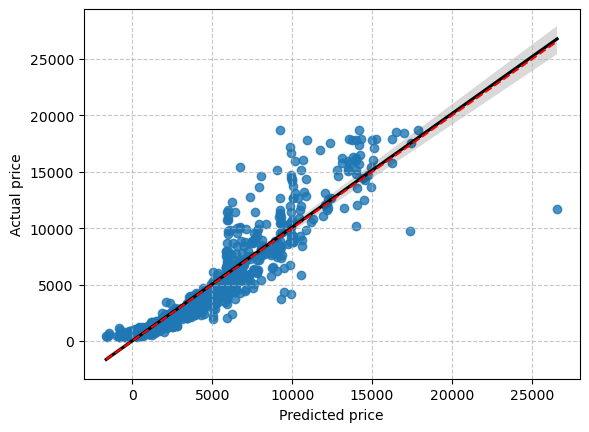

In [61]:
# Your existing plot
sns.regplot(x=y_pred, y=y_actual, line_kws={'color': 'black'})
plt.xlabel("Predicted price")
plt.ylabel("Actual price")
plt.grid(alpha=0.7, linestyle="--")

# Adding the perfect y = x line
plt.plot([min(y_pred), max(y_pred)], [min(y_pred), max(y_pred)], color='red', linestyle='--')

plt.show()

In [62]:
# Multiple R
print(type(y_pred))
print(type(y_actual))

<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>


In [63]:
y_pred.corr(y_actual)

np.float64(0.9277629181426229)

In [64]:
residuals = y_actual - y_pred
residuals.head()

0     702.053034
1     863.354322
2     703.053034
3    1186.813195
4    1885.781485
dtype: float64

In [65]:
MAE = residuals.abs().mean()
print(MAE)

992.6128382942114
